# `==== GRAD-CAM =====`

In [18]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
import torch.nn as nn
import torchvision.models as models

In [19]:
MEAN = [0.47889522, 0.47227842, 0.43047404]
STD  = [0.24205776, 0.23828046, 0.25874835]
IMAGE_SIZE = 32
CINIC10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [20]:
preprocess_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(
        mean=MEAN,
        std=STD,
        max_pixel_value=255.0),
    ToTensorV2(),])

### Creating grad-cam interpretations

In [21]:
CINIC10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

preprocess_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

def preprocess_image(image_path):

    img_pil = Image.open(image_path).convert('RGB')
    
    img_tensor = preprocess_transform(img_pil).unsqueeze(0)
    
    img_original = np.array(img_pil.resize((32, 32))) 
    
    return img_tensor, img_original

def get_conv_layer(model, conv_layer_name):
    for name, layer in model.named_modules():
        if name == conv_layer_name:
            return layer
    raise ValueError(f"Warstwa {conv_layer_name} nie została znaleziona w modelu.")

def compute_grad_cam_pp(model, img_tensor, class_index, conv_layer_name):
    model.eval()
    model.zero_grad()

    target_layer = get_conv_layer(model, conv_layer_name)

    activations = []
    gradients = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    fh = target_layer.register_forward_hook(forward_hook)
    bh = target_layer.register_full_backward_hook(backward_hook)

    output = model(img_tensor)
    score = output[:, class_index]
    score.backward(retain_graph=False)

    fh.remove()
    bh.remove()

    A = activations[0][0]
    G = gradients[0][0]

    G2 = G ** 2
    G3 = G ** 3
    eps = 1e-8
    sum_A_G3 = torch.sum(A * G3, dim=(1, 2), keepdim=True)
    alpha = G2 / (2 * G2 + sum_A_G3 + eps)

    positive_gradients = torch.relu(G)
    weights = torch.sum(alpha * positive_gradients, dim=(1, 2), keepdim=True)

    cam = torch.sum(weights * A, dim=0)
    cam = torch.relu(cam)
    cam -= cam.min()
    cam /= cam.max() + eps

    return cam.detach().cpu().numpy()

def overlay_heatmap(img_rgb, heatmap, alpha=0.6):

    heatmap = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    
    heatmap_rgb = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    superimposed_img = cv2.addWeighted(img_rgb, alpha, heatmap_rgb, 1 - alpha, 0)
    return superimposed_img

def display_heatmaps(model, image_path, layer_name='layer4.1.conv2', device='cuda'):
    img_tensor, img_original = preprocess_image(image_path)
    img_tensor = img_tensor.to(device)
    
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    plt.suptitle(f"Grad-CAM++ Heatmaps at layer: {layer_name}", fontsize=18)
    
    for c in range(10):
        heatmap = compute_grad_cam_pp(model, img_tensor, c, layer_name)
        output_image = overlay_heatmap(img_original, heatmap)
        
        axes[c].imshow(output_image)
        axes[c].set_title(f"{CINIC10_CLASSES[c]} (idx: {c})", fontsize=12)
        axes[c].axis('off')
        
    plt.tight_layout()
    plt.show()

In [22]:
def get_resnet18_for_cinic10(num_classes=10, use_pretrained=True, dropout=0.0, freeze_pretrained=True):

    weights = models.ResNet18_Weights.DEFAULT if use_pretrained else None
    model = models.resnet18(weights=weights)

    if use_pretrained and freeze_pretrained:
        for param in model.parameters():
            param.requires_grad = False 


    model.conv1 = nn.Conv2d(
        in_channels=3, 
        out_channels=64, 
        kernel_size=3, 
        stride=1, 
        padding=1, 
        bias=False
    )
    model.maxpool = nn.Identity()

    num_ftrs = model.fc.in_features
    if dropout > 0:
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(num_ftrs, num_classes)
        )
    else:
        model.fc = nn.Linear(num_ftrs, num_classes)

    return model

In [23]:
def predict_single_image(model, image_path, device='cuda'):
    model.eval()
    
    img_tensor, _ = preprocess_image(image_path)
    img_tensor = img_tensor.to(device)
    
    with torch.no_grad():
        output = model(img_tensor)
        
        probabilities = F.softmax(output[0], dim=0)
        
        top_prob, top_class_idx = torch.topk(probabilities, 1)
        
    pred_idx = top_class_idx.item()
    pred_prob = top_prob.item() * 100
    pred_class_name = CINIC10_CLASSES[pred_idx]
    
    print(f"--- Prediction ---")
    print(f"Predicted class: **{pred_class_name}** (Index: {pred_idx})")
    print(f"Probability: {pred_prob:.2f}%")
    
    return pred_idx, pred_class_name, pred_prob

In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = get_resnet18_for_cinic10(
    num_classes=10, 
    use_pretrained=True, 
    dropout=0.2,
    freeze_pretrained=False
).to(device)
model.load_state_dict(torch.load('./resnet18/models/model_flip_1.pth', map_location=device))

C:\Users\macie\AppData\Local\Temp\ipykernel_4316\1210647642.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('./resnet18/models/model_fli

<All keys matched successfully>

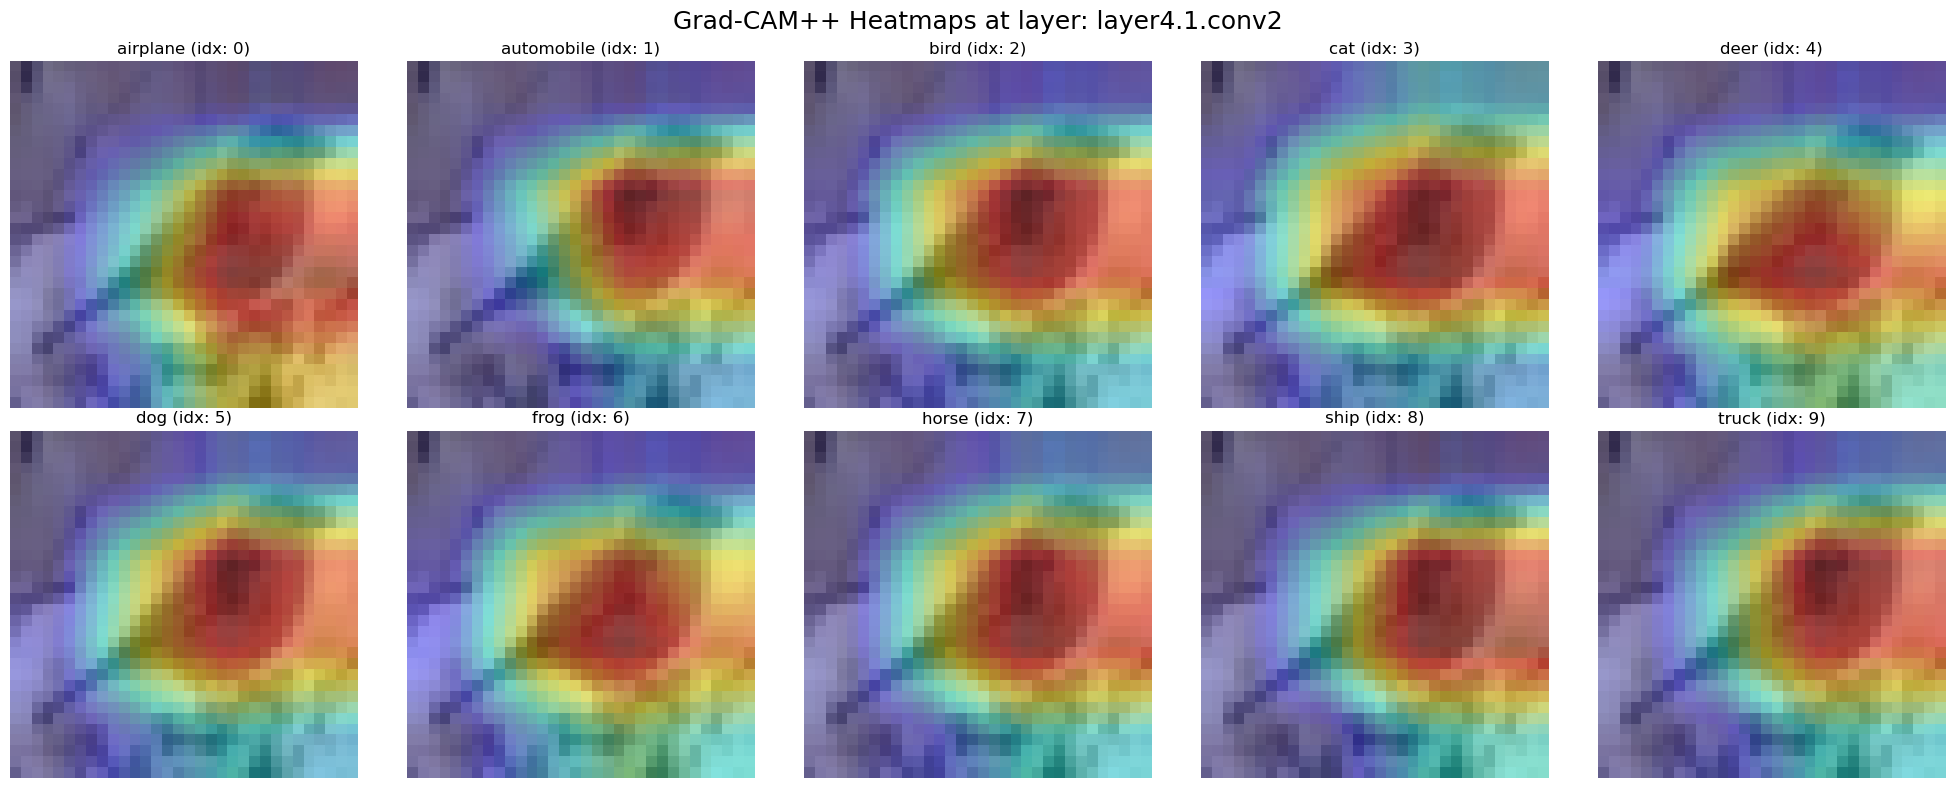

In [30]:
sample_image = '../cifar10-train-10018.png' 

display_heatmaps(model, sample_image, layer_name='layer4.1.conv2', device=device)

In [31]:
predicted_index, predicted_name, confidence = predict_single_image(model, sample_image, device=device)

--- Prediction ---
Predicted class: **bird** (Index: 2)
Probability: 100.00%


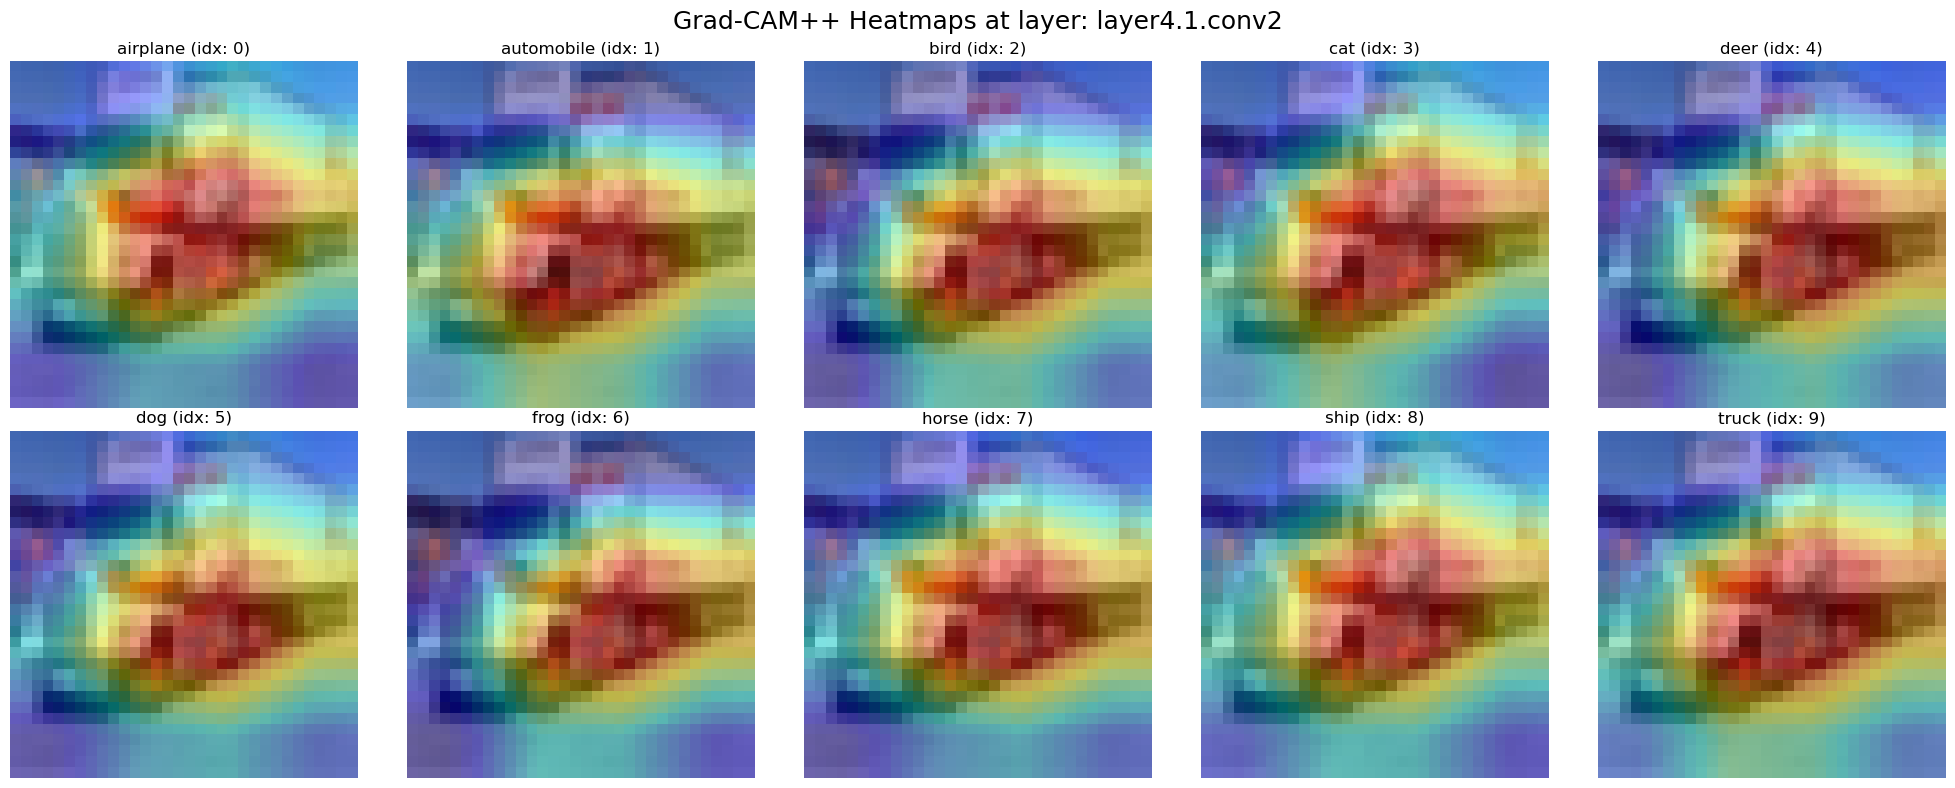

In [42]:
sample_image = '../cifar10-train-10161.png' 

display_heatmaps(model, sample_image, layer_name='layer4.1.conv2', device=device)

In [43]:
predicted_index, predicted_name, confidence = predict_single_image(model, sample_image, device=device)

--- Prediction ---
Predicted class: **truck** (Index: 9)
Probability: 99.99%
